In [2]:
import pandas as pd
import re
import requests
import scipy as sp
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import csv
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [15]:
data = pd.read_csv('Final Consolidated Doses.csv')

print(data.head())
print(data.info())
print(f"Missing values:\n{data.isnull().sum()}")

    base_name              indication mg_per_dose     dosing_period  \
0  adalimumab    rheumatoid arthritis          40  every other week   
1  adalimumab     psoriatic arthritis          40  every other week   
2  adalimumab  ankylosing spondylitis          40  every other week   
3  adalimumab         crohn's disease          40  every other week   
4  adalimumab      ulcerative colitis          40  every other week   

  daily_dose                                       dosage_forms  \
0       2.86  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...   
1       2.86  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...   
2       2.86  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...   
3       2.86  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...   
4       2.86  10/0.1 syringe|20/0.2 syringe|20/0.4 syringe|4...   

               ephmra_code  
0  L4B (Anti-TNF Products)  
1  L4B (Anti-TNF Products)  
2  L4B (Anti-TNF Products)  
3  L4B (Anti-TNF Products)  
4  L4B (Anti-TNF Products

In [16]:
# Count unique products per EphMRA code (product-level), then by first-level EphMRA grouping.
import re

def extract_first_level(code):
    if not isinstance(code, str):
        return None
    token = code.split('(')[0].strip()
    token = token.replace(' ', '')
    m = re.match(r'^([A-Za-z]+\d+)', token)
    return m.group(1) if m else token or None

# Ensure ephmra_code present
df = data.copy()
df = df.dropna(subset=['ephmra_code'])

# Full-code product counts (existing)
product_counts_by_ephmra = (
    df.groupby('ephmra_code')
    .agg(unique_products=('base_name', 'nunique'), total_rows=('base_name', 'size'))
    .sort_values(['unique_products', 'total_rows'], ascending=[False, False])
)
product_counts_by_ephmra = product_counts_by_ephmra.reset_index()
product_counts_by_ephmra['ephmra_code'] = product_counts_by_ephmra['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
product_counts_by_ephmra = product_counts_by_ephmra.set_index('ephmra_code')

print('Unique products per full EphMRA code:')
print(product_counts_by_ephmra.head(40))

df['ephmra_token'] = df['ephmra_code'].astype(str).apply(lambda s: s.split('(')[0].strip())
# First-level grouping (consistent single prefix like 'L1', 'C10', 'N7')
df['ephmra_one'] = df['ephmra_token'].apply(extract_first_level)

one_level_counts = (
    df.dropna(subset=['ephmra_one'])
    .groupby('ephmra_one')
    .agg(unique_products=('base_name', 'nunique'), total_rows=('base_name', 'size'))
    .sort_values(['unique_products', 'total_rows'], ascending=[False, False])
)

print('\nUnique products per EphMRA first-level grouping:')
print(one_level_counts.head(60))


Unique products per full EphMRA code:
             unique_products  total_rows
ephmra_code                             
L1G9                      26          58
L1G5                      11          69
L4C                        9          25
L1G3                       7          17
L1G1                       6          18
N7A                        5          11
L4B                        4          24
L1G4                       4          10
L4E                        4          10
R3M                        4           8
L4X                        4           5
N2C2                       4           5
S1P                        3          10
D5X                        3           4
M5X                        3           4
L1G2                       2          16
C10A4                      2           8
B2D3                       2           4
J1X9                       2           4
N7X                        2           4
L4X                        2           3
B6D                

In [17]:
# Model 1: daily dose distribution across full EphMRA codes using one daily dose per unique product.
def parse_daily_dose(value):
    if pd.isna(value):
        return np.nan
    parts = [part.strip() for part in str(value).split('|') if part.strip()]
    numeric_parts = pd.to_numeric(pd.Series(parts), errors='coerce').dropna()
    if numeric_parts.empty:
        return np.nan
    return round(float(numeric_parts.mean()), 2)

dose_df = data[['base_name', 'ephmra_code', 'daily_dose']].dropna(subset=['base_name', 'ephmra_code', 'daily_dose']).copy()
dose_df['daily_dose_avg'] = dose_df['daily_dose'].apply(parse_daily_dose)
dose_df = dose_df.dropna(subset=['daily_dose_avg'])

# Build one representative daily dose per unique product by taking the most frequent value across indications.
product_daily_dose = (
    dose_df.groupby(['ephmra_code', 'base_name'], as_index=False)
    .agg(
        representative_daily_dose=('daily_dose_avg', lambda s: s.value_counts().sort_index(ascending=True).idxmax()),
        indication_rows=('daily_dose_avg', 'size'),
    )
)

ephmra_product_counts = (
    product_daily_dose.groupby('ephmra_code')['base_name']
    .nunique()
    .reset_index(name='unique_products')
)
eligible_ephmra_codes = ephmra_product_counts.loc[ephmra_product_counts['unique_products'] > 3, 'ephmra_code']

model1_df = product_daily_dose[product_daily_dose['ephmra_code'].isin(eligible_ephmra_codes)].copy()

model1_summary = (
    model1_df.groupby('ephmra_code')['representative_daily_dose']
    .agg(n='count', mean='mean', std='std', median='median', min='min', max='max')
    .sort_values(['n', 'mean'], ascending=[False, True])
)
model1_summary = model1_summary.reset_index()
model1_summary['ephmra_code'] = model1_summary['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
model1_summary = model1_summary.set_index('ephmra_code')

print('=== MODEL 1: Representative daily dose distribution by full EphMRA code ===')
print('Unique product daily dose definition:')
print('- If daily_dose contains multiple values separated by |, they are averaged first.')
print('- If a base_name appears multiple times across indications, the most frequent daily dose is kept.')
print('- Only full EphMRA codes with more than 3 unique products are included.')
print()
print(model1_summary)

# Optional normal fit parameters for each code.
model1_normal_fit_rows = []
for ephmra_code, group in model1_df.groupby('ephmra_code'):
    values = group['representative_daily_dose'].dropna().to_numpy()
    if len(values) == 0:
        continue
    normal_mu, normal_sigma = sp.stats.norm.fit(values)
    model1_normal_fit_rows.append({
        'ephmra_code': ephmra_code,
        'normal_mu': normal_mu,
        'normal_sigma': normal_sigma,
    })
model1_normal_fit = pd.DataFrame(model1_normal_fit_rows).sort_values('normal_mu', ascending=False)
model1_normal_fit['ephmra_code'] = model1_normal_fit['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
model1_normal_fit = model1_normal_fit.set_index('ephmra_code')

print()
print('=== MODEL 1: Normal fit parameters by full EphMRA code ===')
print(model1_normal_fit)


=== MODEL 1: Representative daily dose distribution by full EphMRA code ===
Unique product daily dose definition:
- If daily_dose contains multiple values separated by |, they are averaged first.
- If a base_name appears multiple times across indications, the most frequent daily dose is kept.
- Only full EphMRA codes with more than 3 unique products are included.

              n       mean        std  median    min     max
ephmra_code                                                 
L1G9         26  14.401154  14.744250   9.165   0.03   48.57
L1G5         11  31.825455  27.624571  15.800   9.55   86.30
L4C           9   9.490000   4.673414   8.930   2.47   15.00
L1G3          7  36.764286  23.775765  24.000  12.00   76.92
L1G1          6   2.268333   1.966209   1.505   0.61    5.48
N7A           5   4.614000   3.691291   4.170   0.30   10.11
N2C2          4   4.262500   2.219375   3.725   2.20    7.40
R3M           4   4.872500   4.093917   4.905   0.55    9.13
L4X           4   8.920

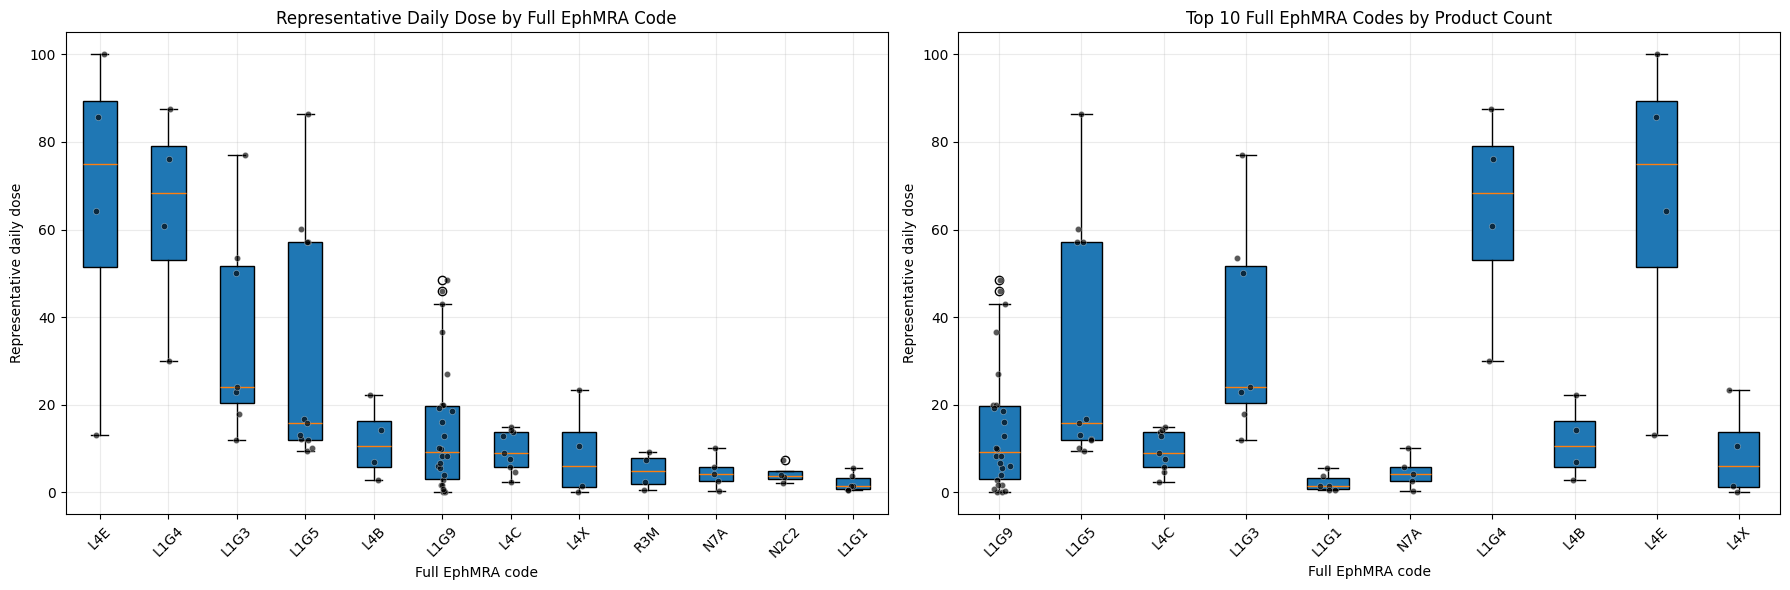

In [18]:
# MODEL 1 box plots (representative daily-dose distributions by full EphMRA code)
if 'model1_df' not in globals():
    print('Run Model 1 first to create model1_df.')
else:
    plot_df = model1_df[['ephmra_code', 'base_name', 'representative_daily_dose']].copy()
    plot_df['ephmra_code_short'] = plot_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    plot_df = plot_df.dropna(subset=['representative_daily_dose'])

    # Full panel order: by median representative daily dose (descending)
    code_order = (
        plot_df.groupby('ephmra_code')['representative_daily_dose']
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    # Top-10 panel order: by unique product count (descending)
    top_code_order = (
        plot_df.groupby('ephmra_code')['base_name']
        .nunique()
        .sort_values(ascending=False)
        .head(10)
        .index
        .tolist()
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    def boxplot_with_dots(ax, frame, order, title):
        groups = [frame.loc[frame['ephmra_code'] == code, 'representative_daily_dose'].values for code in order]
        label_map = frame.drop_duplicates('ephmra_code').set_index('ephmra_code')['ephmra_code_short'].to_dict()
        display_labels = [label_map.get(code, code) for code in order]

        ax.boxplot(groups, tick_labels=display_labels, patch_artist=True)
        for idx, values in enumerate(groups, start=1):
            jitter = np.random.normal(loc=idx, scale=0.05, size=len(values))
            ax.scatter(jitter, values, s=20, alpha=0.65, color='black', edgecolors='white', linewidths=0.3, zorder=3)
        ax.set_title(title)
        ax.set_xlabel('Full EphMRA code')
        ax.set_ylabel('Representative daily dose')
        ax.grid(alpha=0.25)
        ax.tick_params(axis='x', rotation=45)

    # Box plot A: all eligible full EphMRA codes
    boxplot_with_dots(axes[0], plot_df, code_order, 'Representative Daily Dose by Full EphMRA Code')

    # Box plot B: top 10 codes by unique product count
    top_plot_df = plot_df[plot_df['ephmra_code'].isin(top_code_order)].copy()
    boxplot_with_dots(axes[1], top_plot_df, top_code_order, 'Top 10 Full EphMRA Codes by Product Count')

    plt.tight_layout()
    plt.show()

In [19]:
# MODEL 1 significance + predictive validation (EphMRA code -> representative daily dose)
if 'model1_df' not in globals() or len(model1_df) == 0:
    print('Run Model 1 first to create model1_df.')
else:
    from sklearn.model_selection import KFold
    from sklearn.metrics import mean_squared_error

    stats_df = model1_df[['ephmra_code', 'base_name', 'representative_daily_dose']].dropna().copy()
    stats_df['ephmra_code_short'] = stats_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()
    stats_df['log_dose'] = np.log1p(stats_df['representative_daily_dose'])

    # ----- 1) Global significance tests across EphMRA groups -----
    grouped = [g['log_dose'].values for _, g in stats_df.groupby('ephmra_code_short')]
    k_groups = len(grouped)
    n_total = len(stats_df)

    if k_groups < 2:
        print('Not enough EphMRA groups for inferential testing.')
    else:
        # One-way ANOVA on log-dose
        anova_f, anova_p = sp.stats.f_oneway(*grouped)

        # Eta-squared effect size
        grand_mean = stats_df['log_dose'].mean()
        ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in grouped)
        ss_total = np.sum((stats_df['log_dose'] - grand_mean) ** 2)
        eta_squared = ss_between / ss_total if ss_total > 0 else np.nan

        # Kruskal-Wallis (non-parametric)
        kruskal_h, kruskal_p = sp.stats.kruskal(*grouped)
        epsilon_squared = (kruskal_h - k_groups + 1) / (n_total - k_groups) if (n_total - k_groups) > 0 else np.nan

        inferential_summary = pd.DataFrame([
            {
                'test': 'ANOVA on log1p(dose)',
                'statistic': anova_f,
                'p_value': anova_p,
                'effect_size_name': 'eta_squared',
                'effect_size': eta_squared,
            },
            {
                'test': 'Kruskal-Wallis on log1p(dose)',
                'statistic': kruskal_h,
                'p_value': kruskal_p,
                'effect_size_name': 'epsilon_squared',
                'effect_size': epsilon_squared,
            },
        ])

        print('=== MODEL 1: Global significance tests (EphMRA code vs representative daily dose) ===')
        print(inferential_summary.round(6).to_string(index=False))

    # ----- 2) Predictive validation: baseline vs EphMRA-only model -----
    # Baseline predicts train-fold mean dose; model predicts from EphMRA code only.
    X = stats_df[['ephmra_code_short']].copy()
    y = stats_df['representative_daily_dose'].values

    n_splits = 5 if len(stats_df) >= 25 else 3
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    baseline_rows = []
    model_rows = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Baseline
        yhat_base = np.repeat(np.mean(y_train), len(y_test))
        baseline_rows.append({
            'fold': fold_idx,
            'r2': r2_score(y_test, yhat_base),
            'mae': mean_absolute_error(y_test, yhat_base),
            'rmse': mean_squared_error(y_test, yhat_base) ** 0.5,
        })

        # EphMRA-only model
        model = Pipeline(steps=[
            ('prep', ColumnTransformer(
                transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short'])],
                remainder='drop',
            )),
            ('reg', LinearRegression()),
        ])
        model.fit(X_train, y_train)
        yhat_model = model.predict(X_test)

        model_rows.append({
            'fold': fold_idx,
            'r2': r2_score(y_test, yhat_model),
            'mae': mean_absolute_error(y_test, yhat_model),
            'rmse': mean_squared_error(y_test, yhat_model) ** 0.5,
        })

    baseline_cv = pd.DataFrame(baseline_rows)
    model_cv = pd.DataFrame(model_rows)

    cv_summary = pd.DataFrame([
        {
            'model': 'Baseline (global mean)',
            'cv_r2_mean': baseline_cv['r2'].mean(),
            'cv_mae_mean': baseline_cv['mae'].mean(),
            'cv_rmse_mean': baseline_cv['rmse'].mean(),
        },
        {
            'model': 'EphMRA-only linear model',
            'cv_r2_mean': model_cv['r2'].mean(),
            'cv_mae_mean': model_cv['mae'].mean(),
            'cv_rmse_mean': model_cv['rmse'].mean(),
        },
    ])

    uplift = pd.DataFrame([
        {
            'metric': 'delta_r2 (model - baseline)',
            'value': model_cv['r2'].mean() - baseline_cv['r2'].mean(),
        },
        {
            'metric': 'mae_reduction_pct',
            'value': 100 * (baseline_cv['mae'].mean() - model_cv['mae'].mean()) / baseline_cv['mae'].mean() if baseline_cv['mae'].mean() != 0 else np.nan,
        },
        {
            'metric': 'rmse_reduction_pct',
            'value': 100 * (baseline_cv['rmse'].mean() - model_cv['rmse'].mean()) / baseline_cv['rmse'].mean() if baseline_cv['rmse'].mean() != 0 else np.nan,
        },
    ])

    print('\n=== MODEL 1: Cross-validated predictive performance ===')
    print(cv_summary.round(6).to_string(index=False))
    print('\n=== MODEL 1: Predictive uplift from EphMRA code ===')
    print(uplift.round(6).to_string(index=False))

    # ----- 3) Permutation test on predictive R2 -----
    # Null: EphMRA labels are not related to dose.
    observed_r2 = model_cv['r2'].mean()
    n_perm = 500
    perm_r2 = []

    split_indices = list(kf.split(X))
    for i in range(n_perm):
        X_perm = X.copy()
        X_perm['ephmra_code_short'] = np.random.permutation(X_perm['ephmra_code_short'].values)

        fold_r2 = []
        for train_idx, test_idx in split_indices:
            X_train, X_test = X_perm.iloc[train_idx], X_perm.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            perm_model = Pipeline(steps=[
                ('prep', ColumnTransformer(
                    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short'])],
                    remainder='drop',
                )),
                ('reg', LinearRegression()),
            ])
            perm_model.fit(X_train, y_train)
            yhat_perm = perm_model.predict(X_test)
            fold_r2.append(r2_score(y_test, yhat_perm))

        perm_r2.append(np.mean(fold_r2))

    perm_r2 = np.array(perm_r2)
    p_perm = (np.sum(perm_r2 >= observed_r2) + 1) / (n_perm + 1)

    permutation_summary = pd.DataFrame([
        {
            'observed_cv_r2': observed_r2,
            'perm_mean_r2': perm_r2.mean(),
            'perm_std_r2': perm_r2.std(ddof=1),
            'perm_p_value_one_sided': p_perm,
            'n_permutations': n_perm,
        }
    ])

    print('\n=== MODEL 1: Permutation test for predictive signal ===')
    print(permutation_summary.round(6).to_string(index=False))


=== MODEL 1: Global significance tests (EphMRA code vs representative daily dose) ===
                         test  statistic  p_value effect_size_name  effect_size
         ANOVA on log1p(dose)   6.467961 0.000000      eta_squared     0.483512
Kruskal-Wallis on log1p(dose)  43.908976 0.000008  epsilon_squared     0.433013

=== MODEL 1: Cross-validated predictive performance ===
                   model  cv_r2_mean  cv_mae_mean  cv_rmse_mean
  Baseline (global mean)   -0.058859    17.982880     23.724448
EphMRA-only linear model    0.190202    13.818064     19.754979

=== MODEL 1: Predictive uplift from EphMRA code ===
                     metric     value
delta_r2 (model - baseline)  0.249061
          mae_reduction_pct 23.159895
         rmse_reduction_pct 16.731555

=== MODEL 1: Permutation test for predictive signal ===
 observed_cv_r2  perm_mean_r2  perm_std_r2  perm_p_value_one_sided  n_permutations
       0.190202     -0.318415     0.160441                0.001996             5

In [20]:
# MODEL 1: predicted representative daily dose per EphMRA code (expanded stats)
if 'model1_df' not in globals() or len(model1_df) == 0:
    print('Run Model 1 first to create model1_df.')
else:
    pred_df = model1_df[['ephmra_code', 'base_name', 'representative_daily_dose']].dropna().copy()
    pred_df['ephmra_code_short'] = pred_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()

    # Fit EphMRA-only model on full data, then generate fitted predictions.
    pred_model = Pipeline(steps=[
        ('prep', ColumnTransformer(
            transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['ephmra_code_short'])],
            remainder='drop',
        )),
        ('reg', LinearRegression()),
    ])

    pred_model.fit(pred_df[['ephmra_code_short']], pred_df['representative_daily_dose'])
    pred_df['predicted_daily_dose'] = pred_model.predict(pred_df[['ephmra_code_short']])
    pred_df['residual'] = pred_df['representative_daily_dose'] - pred_df['predicted_daily_dose']

    # Build richer per-code summary.
    predictions_per_code = (
        pred_df.groupby('ephmra_code_short')
        .agg(
            n_products=('base_name', 'nunique'),
            actual_mean_daily_dose=('representative_daily_dose', 'mean'),
            predicted_daily_dose=('predicted_daily_dose', 'mean'),
            std_daily_dose=('representative_daily_dose', 'std'),
            median_daily_dose=('representative_daily_dose', 'median'),
            q1_daily_dose=('representative_daily_dose', lambda s: s.quantile(0.25)),
            q3_daily_dose=('representative_daily_dose', lambda s: s.quantile(0.75)),
            min_daily_dose=('representative_daily_dose', 'min'),
            max_daily_dose=('representative_daily_dose', 'max'),
            mae_within_code=('residual', lambda s: np.mean(np.abs(s))),
            rmse_within_code=('residual', lambda s: np.sqrt(np.mean(np.square(s)))),
        )
        .sort_values(['n_products', 'predicted_daily_dose'], ascending=[False, False])
    )

    predictions_per_code['se_mean'] = predictions_per_code['std_daily_dose'] / np.sqrt(predictions_per_code['n_products'])
    predictions_per_code['ci95_low'] = predictions_per_code['actual_mean_daily_dose'] - 1.96 * predictions_per_code['se_mean']
    predictions_per_code['ci95_high'] = predictions_per_code['actual_mean_daily_dose'] + 1.96 * predictions_per_code['se_mean']
    predictions_per_code['ci95_half_width'] = 1.96 * predictions_per_code['se_mean']
    predictions_per_code['iqr_daily_dose'] = predictions_per_code['q3_daily_dose'] - predictions_per_code['q1_daily_dose']
    predictions_per_code['cv_pct'] = np.where(
        predictions_per_code['actual_mean_daily_dose'] != 0,
        100 * predictions_per_code['std_daily_dose'] / predictions_per_code['actual_mean_daily_dose'],
        np.nan,
    )
    predictions_per_code['bias_pred_minus_actual'] = (
        predictions_per_code['predicted_daily_dose'] - predictions_per_code['actual_mean_daily_dose']
    )

    predictions_per_code['predicted_daily_dose_ci95'] = predictions_per_code.apply(
        lambda r: f"{r['predicted_daily_dose']:.2f} (+/- {r['ci95_half_width']:.2f} CI95)",
        axis=1,
    )

    ordered_cols = [
        'n_products',
        'actual_mean_daily_dose',
        'predicted_daily_dose_ci95',
        'bias_pred_minus_actual',
        'std_daily_dose',
        'se_mean',
        'ci95_low',
        'ci95_high',
        'median_daily_dose',
        'q1_daily_dose',
        'q3_daily_dose',
        'iqr_daily_dose',
        'min_daily_dose',
        'max_daily_dose',
        'cv_pct',
        'mae_within_code',
        'rmse_within_code',
    ]

    print('=== MODEL 1: Predictions per EphMRA code (expanded statistics) ===')
    print(predictions_per_code[ordered_cols].round(4).to_string())


=== MODEL 1: Predictions per EphMRA code (expanded statistics) ===
                   n_products  actual_mean_daily_dose predicted_daily_dose_ci95  bias_pred_minus_actual  std_daily_dose  se_mean  ci95_low  ci95_high  median_daily_dose  q1_daily_dose  q3_daily_dose  iqr_daily_dose  min_daily_dose  max_daily_dose    cv_pct  mae_within_code  rmse_within_code
ephmra_code_short                                                                                                                                                                                                                                                                                  
L1G9                       26                 14.4012     14.40 (+/- 5.67 CI95)                     0.0         14.7443   2.8916    8.7336    20.0687              9.165         3.0700        19.7925         16.7225            0.03           48.57  102.3824          11.6283           14.4579
L1G5                       11                 31.8255    

In [21]:
# MODEL 1: outlier review by EphMRA code with original CSV row indices
if 'data' not in globals():
    print('Load the data first.')
else:
    def parse_daily_dose_for_review(value):
        if pd.isna(value):
            return np.nan
        parts = [part.strip() for part in str(value).split('|') if part.strip()]
        numeric_parts = pd.to_numeric(pd.Series(parts), errors='coerce').dropna()
        if numeric_parts.empty:
            return np.nan
        return float(numeric_parts.mean())

    # Preserve original CSV row numbers for manual review.
    review_df = data.reset_index().rename(columns={'index': 'csv_row_index'}).copy()
    review_df['csv_line_number'] = review_df['csv_row_index'] + 2
    review_df['daily_dose_avg'] = review_df['daily_dose'].apply(parse_daily_dose_for_review)
    review_df['ephmra_code_short'] = review_df['ephmra_code'].astype(str).str.split('(').str[0].str.strip()

    # Collapse to one product-level row per EphMRA code and base_name while retaining source rows.
    product_review_df = (
        review_df.dropna(subset=['ephmra_code_short', 'base_name', 'daily_dose_avg'])
        .groupby(['ephmra_code_short', 'base_name'], as_index=False)
        .agg(
            representative_daily_dose=('daily_dose_avg', lambda s: s.value_counts().sort_index(ascending=True).idxmax()),
            n_source_rows=('csv_row_index', 'size'),
            source_row_indices=('csv_row_index', lambda s: sorted(s.unique().tolist())),
            source_line_numbers=('csv_line_number', lambda s: sorted(s.unique().tolist())),
        )
    )

    # IQR outlier bounds within each EphMRA code.
    bounds_df = (
        product_review_df.groupby('ephmra_code_short')['representative_daily_dose']
        .agg(q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
        .reset_index()
    )
    bounds_df['iqr'] = bounds_df['q3'] - bounds_df['q1']
    bounds_df['lower_bound'] = bounds_df['q1'] - 1.5 * bounds_df['iqr']
    bounds_df['upper_bound'] = bounds_df['q3'] + 1.5 * bounds_df['iqr']

    outlier_df = product_review_df.merge(bounds_df, on='ephmra_code_short', how='left')
    outlier_df = outlier_df[
        (outlier_df['representative_daily_dose'] < outlier_df['lower_bound']) |
        (outlier_df['representative_daily_dose'] > outlier_df['upper_bound'])
    ].copy()

    print('=== MODEL 1: IQR outliers by EphMRA code ===')
    if len(outlier_df) == 0:
        print('No IQR outliers found at the product level.')
    else:
        outlier_df['source_row_indices'] = outlier_df['source_row_indices'].apply(lambda x: ', '.join(map(str, x)))
        outlier_df['source_line_numbers'] = outlier_df['source_line_numbers'].apply(lambda x: ', '.join(map(str, x)))

        display_cols = [
            'ephmra_code_short',
            'base_name',
            'representative_daily_dose',
            'q1',
            'q3',
            'iqr',
            'lower_bound',
            'upper_bound',
            'n_source_rows',
            'source_row_indices',
            'source_line_numbers',
        ]

        print(outlier_df[display_cols].sort_values(['ephmra_code_short', 'representative_daily_dose']).round(4).to_string(index=False))

        # Show the exact source CSV rows for manual review.
        source_row_ids = sorted({idx for indices in outlier_df['source_row_indices'].str.split(', ').tolist() for idx in indices})
        source_row_ids = [int(idx) for idx in source_row_ids if str(idx).strip() != '']
        review_rows = review_df[review_df['csv_row_index'].isin(source_row_ids)].copy()
        review_rows = review_rows.sort_values(['ephmra_code_short', 'base_name', 'csv_row_index'])

        print('\n=== Source CSV rows for outlier products ===')
        print(
            review_rows[
                ['csv_row_index', 'csv_line_number', 'base_name', 'indication', 'daily_dose', 'ephmra_code']
            ]
            .to_string(index=False)
        )


=== MODEL 1: IQR outliers by EphMRA code ===
ephmra_code_short    base_name  representative_daily_dose     q1      q3     iqr  lower_bound  upper_bound  n_source_rows source_row_indices source_line_numbers
             L1G9  tafasitamab                      46.03 3.0700 19.7925 16.7225     -22.0138      44.8762              1                314                 316
             L1G9 zolbetuximab                      48.57 3.0700 19.7925 16.7225     -22.0138      44.8762              1                352                 354
              L4X  narsoplimab                      52.86 3.8025 22.5200 18.7175     -24.2738      50.5962              1                202                 204
             N2C2 fremanezumab                       7.40 3.1700  4.8125  1.6425       0.7062       7.2762              1                140                 142

=== Source CSV rows for outlier products ===
 csv_row_index  csv_line_number    base_name                                                            